In [1]:
# ==========================================
# TITANIC CLASSIFICATION SYSTEM
# USING LOGISTIC REGRESSION
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import joblib

In [3]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("tested.csv")

print("First 5 Rows:")
print(df.head())

First 5 Rows:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


In [4]:
# ==========================================
# DROP EMPTY COLUMNS
# ==========================================

print("\nMissing Values Per Column:")
print(df.isnull().sum())

# Drop completely empty columns
df = df.dropna(axis=1, how='all')

# Drop Cabin column because it contains too many missing values
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

print("\nRemaining Columns:")
print(df.columns)


Missing Values Per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Remaining Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [5]:
# ==========================================
# VISUALIZATION
# ==========================================

# Total passengers
total_passengers = len(df)

# Male and female counts
gender_counts = df['Sex'].value_counts()

print("\nTotal Passengers:", total_passengers)
print("\nGender Count:")
print(gender_counts)


Total Passengers: 418

Gender Count:
Sex
male      266
female    152
Name: count, dtype: int64


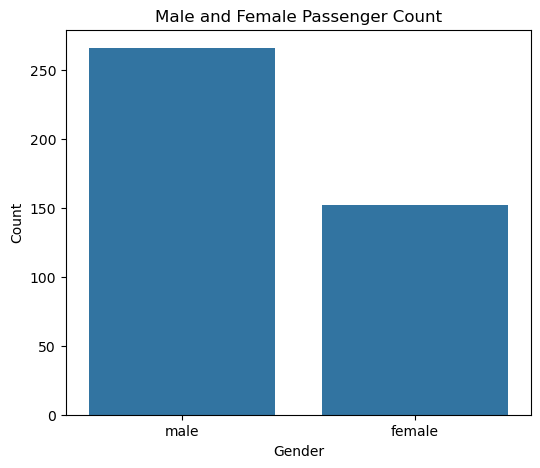

In [6]:
# Plot gender count
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Sex')

plt.title("Male and Female Passenger Count")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [7]:
# ==========================================
# AGE ANALYSIS
# ==========================================

# Fill missing Age values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Mean, Median, Mode
mean_age = df['Age'].mean()
median_age = df['Age'].median()
mode_age = df['Age'].mode()[0]

print("\nMean Age:", mean_age)
print("Median Age:", median_age)
print("Mode Age:", mode_age)


Mean Age: 29.599282296650717
Median Age: 27.0
Mode Age: 27.0


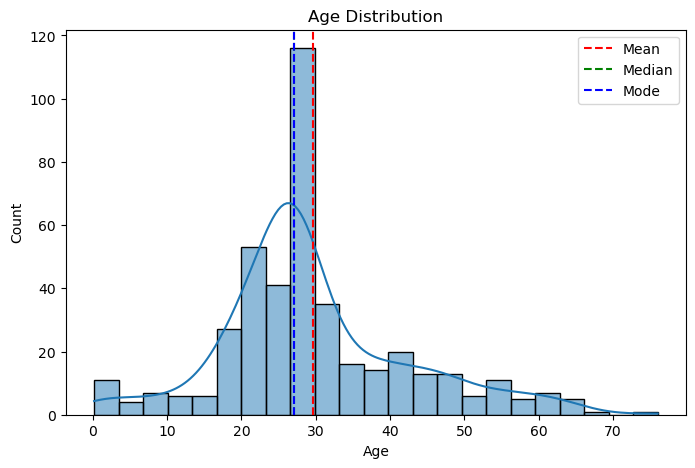

In [8]:
# Distribution plot
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], kde=True)

plt.axvline(mean_age, color='red', linestyle='--', label='Mean')
plt.axvline(median_age, color='green', linestyle='--', label='Median')
plt.axvline(mode_age, color='blue', linestyle='--', label='Mode')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.legend()

plt.show()

In [9]:
# ==========================================
# DROP UNNECESSARY COLUMNS
# ==========================================

# Columns not useful for training
drop_columns = ['PassengerId', 'Name', 'Ticket']

for col in drop_columns:
    if col in df.columns:
        df = df.drop(columns=[col])

print("\nDataset After Dropping Unnecessary Columns:")
print(df.head())


Dataset After Dropping Unnecessary Columns:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  34.5      0      0   7.8292        Q
1         1       3  female  47.0      1      0   7.0000        S
2         0       2    male  62.0      0      0   9.6875        Q
3         0       3    male  27.0      0      0   8.6625        S
4         1       3  female  22.0      1      1  12.2875        S


In [10]:
# ==========================================
# HANDLE MISSING VALUES
# ==========================================

# Fill Embarked missing values
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill Fare missing values
if 'Fare' in df.columns:
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [11]:
# ==========================================
# ENCODE CATEGORICAL DATA
# ==========================================

encoder = LabelEncoder()

# Encode Sex
df['Sex'] = encoder.fit_transform(df['Sex'])

# Encode Embarked
if 'Embarked' in df.columns:
    df['Embarked'] = encoder.fit_transform(df['Embarked'])

print("\nEncoded Dataset:")
print(df.head())


Encoded Dataset:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  34.5      0      0   7.8292         1
1         1       3    0  47.0      1      0   7.0000         2
2         0       2    1  62.0      0      0   9.6875         1
3         0       3    1  27.0      0      0   8.6625         2
4         1       3    0  22.0      1      1  12.2875         2


In [12]:
# ==========================================
# FEATURES AND TARGET
# ==========================================

X = df.drop('Survived', axis=1)
y = df['Survived']

In [13]:
# ==========================================
# SPLIT DATASET
# 70% TRAINING
# 30% TESTING
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (292, 7)
Testing Shape: (126, 7)


In [14]:
# ==========================================
# TRAIN LOGISTIC REGRESSION MODEL
# ==========================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [15]:
# ==========================================
# MAKE PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

In [16]:
# ==========================================
# MODEL EVALUATION
# ==========================================

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[85  0]
 [ 0 41]]


In [17]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy Score:", accuracy)


Accuracy Score: 1.0


In [18]:
# Precision
precision = precision_score(y_test, y_pred)
print("Precision Score:", precision)

Precision Score: 1.0


In [19]:
# Recall
recall = recall_score(y_test, y_pred)
print("Recall Score:", recall)

Recall Score: 1.0


In [20]:
# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 1.0


In [21]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        85
           1       1.00      1.00      1.00        41

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126



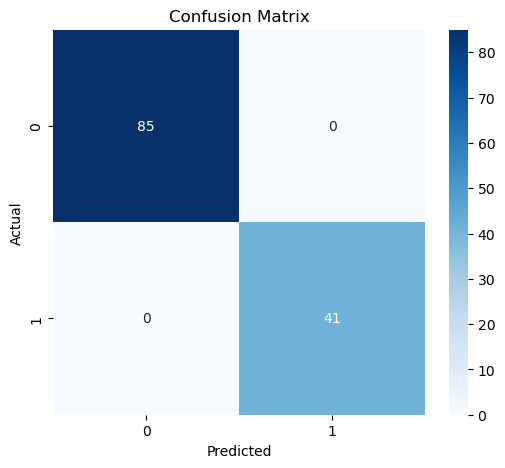

In [22]:

# ==========================================
# VISUALIZE CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
# ==========================================
# SAVE MODEL USING JOBLIB
# ==========================================

joblib.dump(model, "logistic_regression_model.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully


In [24]:
# ==========================================
# LOAD MODEL FOR REAL-TIME PREDICTION
# ==========================================

loaded_model = joblib.load("logistic_regression_model.pkl")

In [26]:
# ==========================================
# REAL-TIME USER INPUT FUNCTION
# ==========================================

def predict_survival():

    print("\n===== Titanic Survival Prediction System =====")

    # User Inputs
    pclass = int(input("Enter Passenger Class (1, 2, or 3): "))

    sex = input("Enter Gender (male/female): ").lower()

    age = float(input("Enter Age: "))

    sibsp = int(input("Enter Number of Siblings/Spouses aboard: "))

    parch = int(input("Enter Number of Parents/Children aboard: "))

    fare = float(input("Enter Fare: "))

    embarked = input("Enter Embarked Port (C/Q/S): ").upper()

    # Encode Sex
    if sex == 'male':
        sex = 1
    else:
        sex = 0

    # Encode Embarked
    embarked_mapping = {
        'C': 0,
        'Q': 1,
        'S': 2
    }

    embarked = embarked_mapping.get(embarked, 2)

    # Create Input Array
    user_data = np.array([[
        pclass,
        sex,
        age,
        sibsp,
        parch,
        fare,
        embarked
    ]])

    # Prediction
    prediction = loaded_model.predict(user_data)

    # Output Result
    if prediction[0] == 1:
        print("\nPrediction: Passenger Survived")
    else:
        print("\nPrediction: Passenger Did Not Survive")

# ==========================================
# RUN PREDICTION SYSTEM
# ==========================================

predict_survival()


===== Titanic Survival Prediction System =====


Enter Passenger Class (1, 2, or 3):  3
Enter Gender (male/female):  female
Enter Age:  47
Enter Number of Siblings/Spouses aboard:  1
Enter Number of Parents/Children aboard:  0
Enter Fare:  7
Enter Embarked Port (C/Q/S):  s



Prediction: Passenger Survived


C:\Users\Anny Jerry\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
